# 01 - Análise Exploratória de Dados (EDA)

**Projeto:** Tech Challenge Fase 1 - Pipeline de Previsão de Churn em Telecom
**Dataset:** Telco Customer Churn (IMB) - 7.043 clientes, 21 features
**Etapa:** 1 - Entedimento e Preparação

## Objetivos da EDA

1. Avaliar **Volume e qualidade** dos dados (missing, duplicados, tipos).
2. Caracterizr **distribuição** das features e da variável-alvo.
3. Identificar **questões de pré-processamento** para a etapa 2.

## 1. Setup

In [1]:
from __future__ import annotations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from churn_predictor.config import RAW_PATH, TARGET_COLUMN, ID_COLUMN, RANDOM_SEED

pd.set_option("display.max_columns", None)


## 2. Carga do Dataset

In [2]:
df_telco = pd.read_csv(RAW_PATH)
print(f"shape: {df_telco.shape}")
df_telco.head().T

shape: (7043, 21)


,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


** O dataset possui 7.043 linhas (clientes) e 21 colunas (features). O customerID aponta para uma identificação única do cliente. A coluna `Churn` é o target dessa análise.

## 3. Visão Geral
**Avaliando os tipos de dados e estatísticas gerais fornecidas pelo Pandas.** 

In [3]:
df_telco.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [4]:
df_telco.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df_telco.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**Pontos de atenção ao analisar o dataset** <br>
Aparentemente não há nenhuma linha vazia, os contadores apontaram para a 7043 linhas preenchidas em todas as features. <br>
No metadados disponível em https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data, a features `SeniorCitizen`deveria ser Yes ou Not, mas aqui no dataset ficou como int64. <br>
A feature `TotalCharges` também retornou diferente do que estava no metadados, aqui o Pandas atribuiu `str`e no Kaggle havia o indicativo de que era uma coluna numérica. <br>
Os pontos observados nessa etapa serão aprofundados no item de qualidade de dados.

## 4. Qualidade dos Dados

### 4.1 Valores ausentes e duplicados

In [6]:
print("Confirmar se não há valores nulos no dataset")
df_telco.isna().sum().sort_values(ascending=False).head(20)

Confirmar se não há valores nulos no dataset


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

In [7]:
print("Testando se existem linhas duplicadas")
print(df_telco.duplicated().sum())

Testando se existem linhas duplicadas
0


In [8]:
print("Verificando se existem clientes duplicados na base:")
print(df_telco['customerID'].duplicated().sum())

Verificando se existem clientes duplicados na base:
0


### 4.2 Inspecionando a feature `SeniorCitizen`

In [9]:
print("Inspecionando a coluna SeniorCitizen")
print(f"\n Valores Únicos {df_telco['SeniorCitizen'].unique()}")
print(df_telco['SeniorCitizen'].value_counts())
print("\n Sem problemas com a variável, vamos assumir que o padrão aqui é booleano, ao invés de string")

Inspecionando a coluna SeniorCitizen

 Valores Únicos [0 1]
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

 Sem problemas com a variável, vamos assumir que o padrão aqui é booleano, ao invés de string


### 4.3 Inspecionando a feature `TotalCharges`

In [10]:
print("Inspecionando a coluna TotalCharges")
print(f"\n Valores Únicos {df_telco['TotalCharges'].unique()}")
#print("Convertendo para números")
#df_telco["TotalCharges"] = df_telco["TotalCharges"].astype(float)

Inspecionando a coluna TotalCharges

 Valores Únicos <ArrowStringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',
 ...
 '2625.25', '6886.25',  '1495.1',   '743.3',  '1419.4',  '1990.5',  '7362.9',
  '346.45',   '306.6',  '6844.5']
Length: 6531, dtype: str


In [11]:
# A variável TotalCharges possui linhas que estão preenchdas com '', isso passou como not null, mas teremos que avaliar o comportamento dessa linha.
subset_espaco = df_telco['TotalCharges'] == " "
linhas_espaco = subset_espaco.sum()
print(f"Linhas com a coluna TotalCharges com espaço: {linhas_espaco}")

# Avaliando se as demais linhas possuem informação relevante ou apresentam alguma ausencia como a identificada
df_telco.loc[subset_espaco, ]

Linhas com a coluna TotalCharges com espaço: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


**Avaliação:** <br>
Apesar da feature `TotalCharges`estar vazia e isso ser um erro, revisando a documentação, a feature `tenure` revela que esses são os meses em que o cliente está na companhia. <br>
Dessa forma, esse conjunto de clientes são novos e ainda não tiveram tempo de realizar o pagamento. <br>
Podemos tratar essa variável de duas formas, ou simplesmente dropamos as linhas e perdemos aproximadamente 0,15% do dataset. Ou podemos substituir as aspas por zero, aparentemente as demais variáveis não apresentaram nenhuma violação de domínio.


## 5. Inspecionando o Target - `Churn`

In [12]:
quantd = df_telco[TARGET_COLUMN].value_counts()
proporcao = df_telco[TARGET_COLUMN].value_counts(normalize=True)

print("Distribuição absoluta:")
print(quantd)
print("\nProporção:")
print(proporcao.round(4))

Distribuição absoluta:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proporção:
Churn
No     0.7346
Yes    0.2654
Name: proportion, dtype: float64


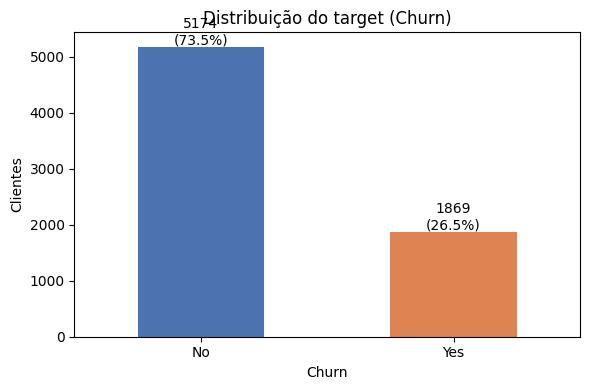

In [13]:
# Plot
fig, ax = plt.subplots(figsize=(6, 4))
quantd.plot(kind="bar", ax=ax, color=["#4c72b0", "#dd8452"])
ax.set_title("Distribuição do target (Churn)")
ax.set_xlabel("Churn")
ax.set_ylabel("Clientes")
ax.tick_params(axis="x", rotation=0)
for i, v in enumerate(quantd.values):
    ax.text(i, v + 50, f"{v}\n({proporcao.iloc[i]*100:.1f}%)",
            ha="center", fontsize=10)
plt.tight_layout()
plt.show()

**Desbalanceamento:** <br>
Quase `74,5%` da base tem No para o Target, com isso apenas `26,5%` temos Yes para o Churn. <br>
Nessa etapa não parece ser necessário nenhuma ação, mas é preciso tomar cuidado escolher a métrica de avaliação do modelo.

## 6. Inspecionando as features numéricas

**Avaliando como as features:** `tenure`, `MonthlyCharges` e `TotalCharges` estão distribuídas, além de avaliar possívies relações com a variável Churn

### 6.1 Distribuições e estatísticas por classe

In [14]:
# Copia de segurança das variáveis numéricas, nesse ponto optou-se por manter as 11 linhas de TotalCharges e alterar seu conteúdo
df_num = df_telco.copy()
df_num["TotalCharges"] = df_num["TotalCharges"].replace(" ", "0").astype(float)

numericas = ["tenure", "MonthlyCharges", "TotalCharges"]
df_num[numericas].describe().round(2)

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73
std,24.56,30.09,2266.79
min,0.00,18.25,0.00
25%,9.00,35.50,398.55
50%,29.00,70.35,1394.55
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


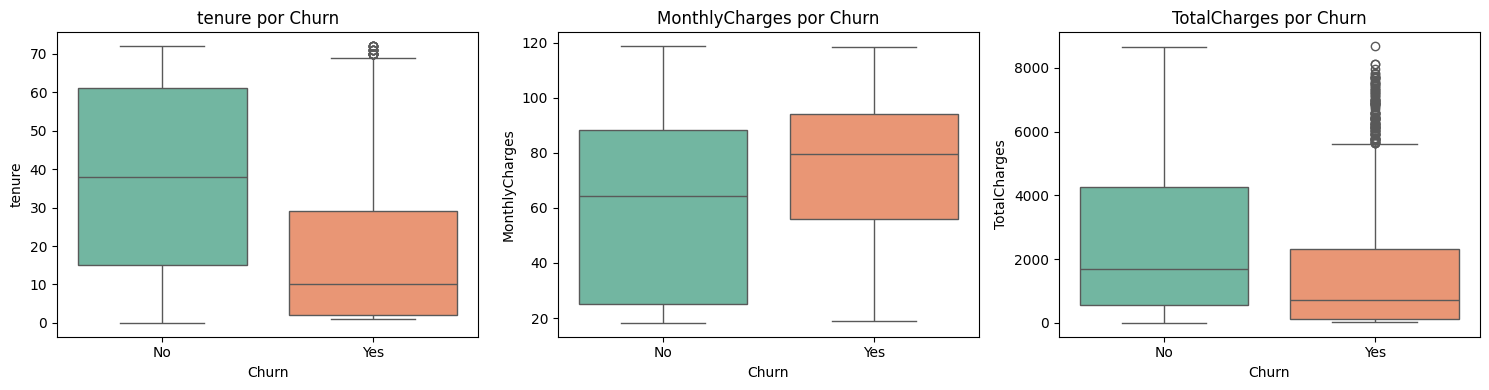

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numericas):
    sns.boxplot(data=df_num, x=TARGET_COLUMN, y=col,
                hue=TARGET_COLUMN, palette="Set2", ax=ax, legend=False)
    ax.set_title(f"{col} por {TARGET_COLUMN}")
plt.tight_layout()
plt.show()

In [16]:
#Média e medianas por classe
df_num.groupby(TARGET_COLUMN)[numericas].agg(["mean", "median"]).round(2)

tenure        MonthlyCharges        TotalCharges         
        mean median           mean median         mean   median
Churn                                                          
No     37.57   38.0          61.27  64.43      2549.91  1679.52
Yes    17.98   10.0          74.44  79.65      1531.80   703.55

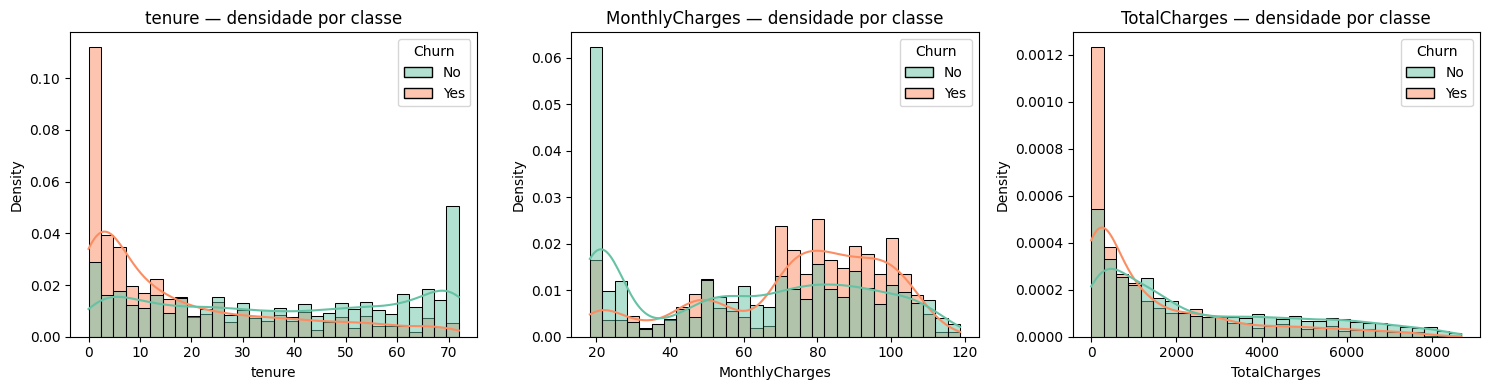

In [17]:
# histograma sobrepostos
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numericas):
    sns.histplot(
        data=df_num, x=col, hue=TARGET_COLUMN,
        stat="density",          # eixo Y = densidade, não contagem
        common_norm=False,       # cada classe normalizada separadamente
        kde=True,                # adiciona a curva KDE suavizada
        bins=30,
        palette="Set2",
        alpha=0.5,
        ax=ax,
    )
    ax.set_title(f"{col} — densidade por classe")
plt.tight_layout()
plt.show()

### 6.2 Hipótese: InternetService como variável de confusão

In [18]:
# Verificar a hipotese: o pico em R$20 e cliente so-telefone?
df_num.groupby("InternetService")["MonthlyCharges"].agg(["count", "mean", "median", "std"]).round(2)

,count,mean,median,std
InternetService,,,,
DSL,2421,58.10,56.15,16.26
Fiber optic,3096,91.50,91.68,12.66
No,1526,21.08,20.15,2.16


In [19]:
# Churn rate por grupo de InternetService
df_num.groupby("InternetService")[TARGET_COLUMN].value_counts(normalize=True).unstack().round(3) * 100

Churn,No,Yes
InternetService,,
DSL,81.0,19.0
Fiber optic,58.1,41.9
No,92.6,7.4


**Constatações:** <br>
- `tenure` parace ser a variável mais forte entre as analisadas. Os clientes Churn-Yes tem mediana de 10 meses, enquanto os Churn-Not tem por volta de 38 meses. A distribuição de churn está bem concentrada nos primeiro meses, clientes saem cedo ou ficam.
- `MonthlyCharges` mais alto correlaciona com churn. Mediana R$ 79,65 para Churn-Yes contra R$ 64,43 para Churn-Not. É possível inferir que quem está pagando mais caro, pode pensar em ir para a concorrência.
- `TotalCharges` tem correlação com `tenure` (acumulado de cobranças). Churners têm `TotalCharges` baixo principalmente porque ficam pouco tempo, não porque pagam pouco.

**Hipótese para modelagem:** essas três numéricas, sozinhas, já levam um modelo simples a um patamar razoável. `tenure × MonthlyCharges` provavelmente é um produto interessante (capacidade de captura para a MLP).

## 7. Correlações entre features numéricas

In [20]:
# Binarizar o target para entrar na matriz como numerica auxiliar
df_corr = df_num.copy()
df_corr["churn_bin"] = (df_corr[TARGET_COLUMN] == "Yes").astype(int)

cols_corr = numericas + ["churn_bin"]
corr_matrix = df_corr[cols_corr].corr(method="pearson").round(3)
corr_matrix

,tenure,MonthlyCharges,TotalCharges,churn_bin
tenure,1.000,0.248,0.826,-0.352
MonthlyCharges,0.248,1.000,0.651,0.193
TotalCharges,0.826,0.651,1.000,-0.198
churn_bin,-0.352,0.193,-0.198,1.000


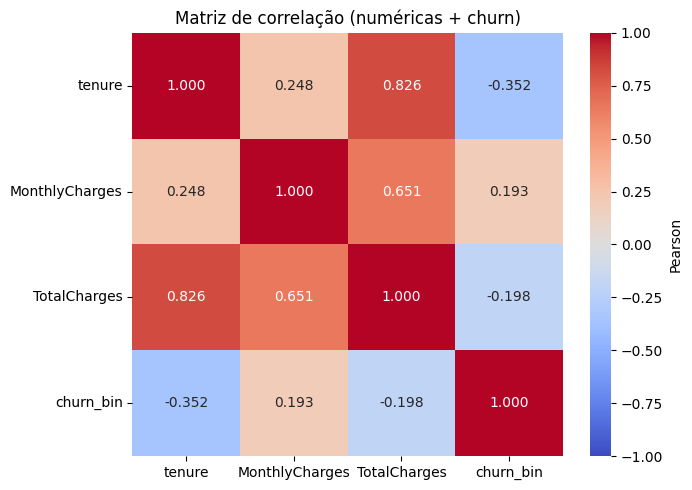

In [21]:
# Heatmap
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, ax=ax,
            cbar_kws={"label": "Pearson"})
ax.set_title("Matriz de correlação (numéricas + churn)")
plt.tight_layout()
plt.show()

In [22]:
# Correção com Churn e ordenada
print("Correlacao com churn (ordenada):")
corr_matrix["churn_bin"].drop("churn_bin").sort_values(key=abs, ascending=False)

Correlacao com churn (ordenada):


tenure           -0.352
TotalCharges     -0.198
MonthlyCharges    0.193
Name: churn_bin, dtype: float64

**Constatações:**

- **`tenure` × `TotalCharges` correlação ~0,83**: alta, esperada (TotalCharges = acumulado de cobranças mensais, função direta de tenure × MonthlyCharges). É **multicolinearidade**, e isso pode ser um problema com Regressões Logísticas.
- **`tenure` é possívelmente a variável com maior poder de previsão** de churn entre as numéricas: correlação ~ -0,35 com `churn_bin` (sinal negativo: mais tempo de contrato → menos churn).
- **`MonthlyCharges` correlação ~+0.19** com churn: positiva (cobrança mensal alta → mais churn). Faz sentido.
- **`TotalCharges` correlação fraca direta**, ~ -0.20, mas é uma função das outras duas — não traz informação independente.

**Implicação:**
- Para Regressão Logística: possivelmente a feature `TotalCharges` será removida.
- Para árvores e MLP: sem alterações.

## 8. Features Categóricas

### 8.1 Cardinalidade e valores únicos

In [36]:
# Selecionar variáveis categóricas
#    customerID é identificador, não precisa ser analisado.
#    Churn é o target, não precisa ser analisado.
categoricas = (
    df_telco.select_dtypes(include=["object", "string"])
    .columns
    .drop([ID_COLUMN, TARGET_COLUMN, "TotalCharges"])
    .tolist()
)
# SeniorCitizen veio como int64 mas conceitualmente é booleano — entra junto.
categoricas.append("SeniorCitizen")

print(f"Total de categóricas: {len(categoricas)}")
print(categoricas)

Total de categóricas: 16
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen']


In [37]:
# Cardinalidade e amostra de valores
resumo_cat = pd.DataFrame({
    "n_unicos": [df_telco[c].nunique() for c in categoricas],
    "valores": [sorted(df_telco[c].astype(str).unique().tolist()) for c in categoricas],
}, index=categoricas)
resumo_cat.sort_values("n_unicos")

,n_unicos,valores
gender,2,"[Female, Male]"
Partner,2,"[No, Yes]"
Dependents,2,"[No, Yes]"
PhoneService,2,"[No, Yes]"
PaperlessBilling,2,"[No, Yes]"
SeniorCitizen,2,"[0, 1]"
MultipleLines,3,"[No, No phone service, Yes]"
InternetService,3,"[DSL, Fiber optic, No]"
OnlineBackup,3,"[No, No internet service, Yes]"
OnlineSecurity,3,"[No, No internet service, Yes]"


**Observação:** sete colunas aparecem com cardinalidade 3 onde esperaríamos
binárias (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` e `MultipleLines`).

### 8.2  Encoding redundante

**Hipótese:** o valor `"No internet service"` (em 6 colunas) ocorre exatamente nas mesmas linhas onde `InternetService == "No"`. Idem para `"No phone service"` em `MultipleLines` vs PhoneService == "No"`. Se confirmado, podemos colapsar esses valores em `"No"` sem perda de informação — reduz dimensionalidade no one-hot encoding.

In [38]:
# Testando a redundância: as 6 colunas de internet
no_internet_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                    "TechSupport", "StreamingTV", "StreamingMovies"]

mask_no_internet = df_telco["InternetService"] == "No"
print(f"Clientes com InternetService=='No': {mask_no_internet.sum()}\n")

for col in no_internet_cols:
    mask_redundante = df_telco[col] == "No internet service"
    igual = (mask_redundante == mask_no_internet).all()
    print(f"  {col:20s}  '{col}'=='No internet service' coincide 1:1? {igual}")

# A coluna do telefone
mask_no_phone = df_telco["PhoneService"] == "No"
mask_ml_redundante = df_telco["MultipleLines"] == "No phone service"
print(f"\nClientes com PhoneService=='No': {mask_no_phone.sum()}")
print(f"  MultipleLines=='No phone service' coincide 1:1? "
      f"{(mask_ml_redundante == mask_no_phone).all()}")

Clientes com InternetService=='No': 1526

  OnlineSecurity        'OnlineSecurity'=='No internet service' coincide 1:1? True
  OnlineBackup          'OnlineBackup'=='No internet service' coincide 1:1? True
  DeviceProtection      'DeviceProtection'=='No internet service' coincide 1:1? True
  TechSupport           'TechSupport'=='No internet service' coincide 1:1? True
  StreamingTV           'StreamingTV'=='No internet service' coincide 1:1? True
  StreamingMovies       'StreamingMovies'=='No internet service' coincide 1:1? True

Clientes com PhoneService=='No': 682
  MultipleLines=='No phone service' coincide 1:1? True


In [39]:
df_cat = df_telco.copy()
df_cat["TotalCharges"] = df_cat["TotalCharges"].replace(" ", "0").astype(float)

# Colapsar "No internet service" -> "No"
for col in no_internet_cols:
    df_cat[col] = df_cat[col].replace("No internet service", "No")

# Colapsar "No phone service" -> "No"
df_cat["MultipleLines"] = df_cat["MultipleLines"].replace("No phone service", "No")

# Confirmar: todas devem ter cardinalidade 2
print("Cardinalidade após o colapso (esperado: tudo 2):")
df_cat[no_internet_cols + ["MultipleLines"]].nunique()

Cardinalidade após o colapso (esperado: tudo 2):


OnlineSecurity      2
OnlineBackup        2
DeviceProtection    2
TechSupport         2
StreamingTV         2
StreamingMovies     2
MultipleLines       2
dtype: int64

**Resultado:** redundância confirmada em todas as 7 colunas afetadas.
Após o colapso, as 7 ficam binárias `Yes`/`No`. A cópia `df_cat` é a versão limpa do DataFrame que vamos usar dessa seção em diante (e salvar em parquet no final da EDA).

### 8.3 Churn rate por categoria

Inspeção das categóricas que o conhecimento de domínio aponta como
discriminativas: `Contract`, `PaymentMethod`, `Dependents` e `Partner`.

In [40]:
def churn_rate_por_categoria(df: pd.DataFrame, col: str,
                             target: str = TARGET_COLUMN) -> pd.DataFrame:
    """Tabela com n, % No, % Yes para cada categoria de `col`, ordenada por churn desc."""
    out = (df.groupby(col)[target]
              .value_counts(normalize=True)
              .unstack(fill_value=0))
    out.columns = [f"{c}_pct" for c in out.columns]
    out = (out * 100).round(1)
    out["n"] = df[col].value_counts()
    return out[["n", "No_pct", "Yes_pct"]].sort_values("Yes_pct", ascending=False)

In [41]:
# aplicar nas 4 hipóteses
for col in ["Contract", "PaymentMethod", "Dependents", "Partner"]:
    print(f"\n--- {col} ---")
    print(churn_rate_por_categoria(df_cat, col))


--- Contract ---
                   n  No_pct  Yes_pct
Contract                             
Month-to-month  3875    57.3     42.7
One year        1473    88.7     11.3
Two year        1695    97.2      2.8

--- PaymentMethod ---
                              n  No_pct  Yes_pct
PaymentMethod                                   
Electronic check           2365    54.7     45.3
Mailed check               1612    80.9     19.1
Bank transfer (automatic)  1544    83.3     16.7
Credit card (automatic)    1522    84.8     15.2

--- Dependents ---
               n  No_pct  Yes_pct
Dependents                       
No          4933    68.7     31.3
Yes         2110    84.5     15.5

--- Partner ---
            n  No_pct  Yes_pct
Partner                       
No       3641    67.0     33.0
Yes      3402    80.3     19.7


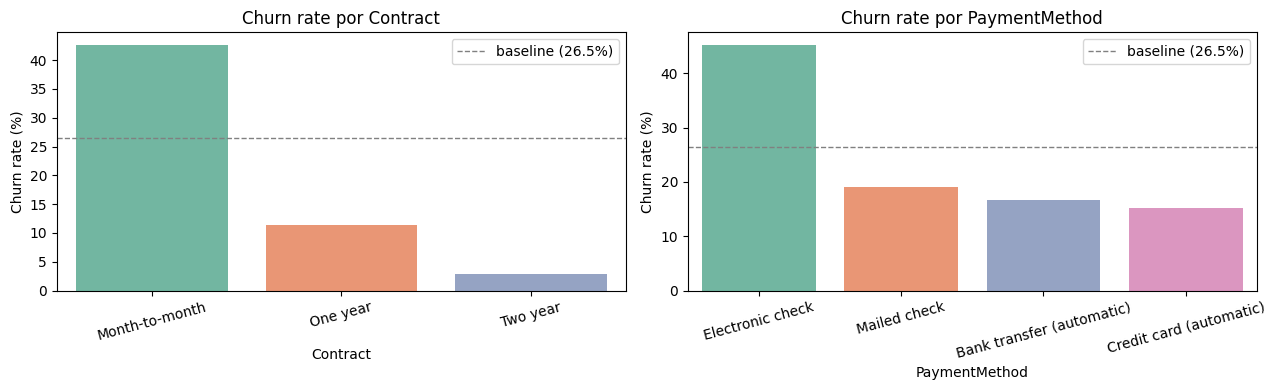

In [42]:
#visualização das duas mais discriminativas
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ["Contract", "PaymentMethod"]):
    rates = churn_rate_por_categoria(df_cat, col).reset_index()
    sns.barplot(data=rates, x=col, y="Yes_pct", ax=ax,
                hue=col, palette="Set2", legend=False)
    ax.axhline(26.5, color="gray", linestyle="--", linewidth=1,
               label="baseline (26.5%)")
    ax.set_title(f"Churn rate por {col}")
    ax.set_ylabel("Churn rate (%)")
    ax.tick_params(axis="x", rotation=15)
    ax.legend()
plt.tight_layout()
plt.show()


**Confirmações:**

- `Contract` é a categórica mais discriminativa visualmente: **Month-to-month ~43%** de churn vs. **Two year ~3%**. Diferença de mais de 14× entre os extremos.
- `PaymentMethod`: **Electronic check ~45%** de churn — bem acima dos demais
  métodos automáticos (~15-19%). Sugere que clientes em métodos manuais têm
  perfil mais volátil.
- `Dependents` e `Partner`: clientes sem dependentes/parceiros têm churn
  ~30-33% vs. ~15-20% — efeito presente mas mais sutil.

A linha tracejada nos gráficos é o churn rate base (26,5%), serve de
referência visual: barras acima → categoria de risco.

### 8.4 Ranking de poder preditivo — Cramér's V

Para ranquear todas as 16 categóricas de forma objetiva, optou-se por utilizar **Cramér's V**: medida de associação entre duas variáveis categóricas
que vai de 0 (independência) a 1 (associação perfeita). É o análogo da correlação Pearson para categóricas.

Implementação manual a partir da tabela de contingência (sem deps novas). A fórmula é:

$$V = \sqrt{\frac{\chi^2}{n \cdot (k-1)}}$$

onde $\chi^2$ é a estatística qui-quadrado, $n$ o tamanho da amostra,
e $k = \min(\text{linhas}, \text{colunas})$ da tabela de contingência.

In [43]:
# função
def cramers_v(x: pd.Series, y: pd.Series) -> float:
    """
    Cramér's V entre duas variáveis categóricas.

    Retorna um float em [0, 1]:
      0 → independência total (chi² == 0)
      1 → associação perfeita (cada valor de x determina y)
    """
    contingency = pd.crosstab(x, y).values
    n = contingency.sum()

    # Frequências esperadas sob hipótese de independência:
    # E[i,j] = (total_linha_i * total_coluna_j) / n
    row_totals = contingency.sum(axis=1, keepdims=True)
    col_totals = contingency.sum(axis=0, keepdims=True)
    expected = row_totals @ col_totals / n

    chi2 = ((contingency - expected) ** 2 / expected).sum()
    k = min(contingency.shape)
    return float(np.sqrt(chi2 / (n * (k - 1))))

In [44]:
# calcular para as 17 variáveis e ranquear
cramers = {col: cramers_v(df_cat[col], df_cat[TARGET_COLUMN])
           for col in categoricas}

ranking_cat = (pd.Series(cramers, name="cramers_v")
                 .sort_values(ascending=False)
                 .round(3)
                 .to_frame())
ranking_cat

,cramers_v
Contract,0.410
InternetService,0.322
PaymentMethod,0.303
PaperlessBilling,0.192
OnlineSecurity,0.171
TechSupport,0.165
Dependents,0.164
SeniorCitizen,0.151
Partner,0.150
OnlineBackup,0.082


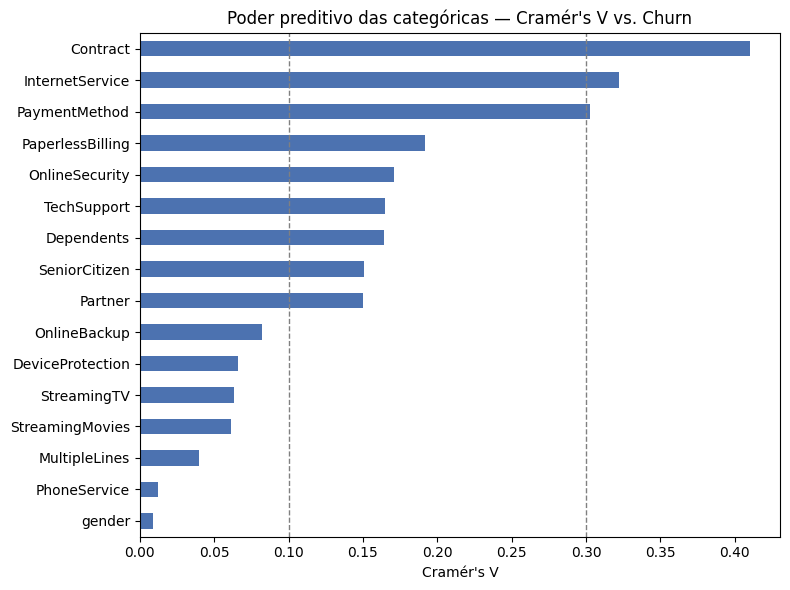

In [45]:
# Visualização da Cramer V
fig, ax = plt.subplots(figsize=(8, 6))
ranking_cat["cramers_v"].sort_values().plot(kind="barh", ax=ax, color="#4c72b0")
ax.set_title("Poder preditivo das categóricas — Cramér's V vs. Churn")
ax.set_xlabel("Cramér's V")
ax.set_ylabel("")
ax.axvline(0.1, color="gray", linestyle="--", linewidth=1)  # ref: associação fraca
ax.axvline(0.3, color="gray", linestyle="--", linewidth=1)  # ref: associação moderada
plt.tight_layout()
plt.show()

**Constatações.**

`Contract` lidera o ranking (V ≈ 0,41), seguida de perto por `InternetService` (0,32) e `PaymentMethod` (0,30). As três descrevem o tipo de relação comercial do cliente — não atributos demográficos. Bate com a leitura intuitiva de churn em telecom: sai quem está em vínculo flexível, com pacote caro, pagando por método manual.

`PaperlessBilling` em 0,19 chama atenção. Não parece informativa por si — é só "fatura digital ou física" — mas funciona como proxy de cliente digital ativo, correlato com Electronic check, Fiber optic e Month-to-month.

Entre os serviços contratáveis há uma separação clara: `OnlineSecurity` e `TechSupport` (~0,17) carregam sinal, enquanto `OnlineBackup`, `DeviceProtection` e os dois Streamings (0,06–0,08) praticamente não. Suporte e segurança aparecem ligados à retenção; armazenamento e entretenimento adicional, não.

`Dependents`, `SeniorCitizen` e `Partner` ficam todos próximos de 0,15 — sinal real, mas modesto. `MultipleLines` (0,04), `PhoneService` (0,01) e `gender` (0,01) são essencialmente independentes do churn. Manteremos por inércia (custo de carregar é zero); a regularização da LogReg ou a importância da árvore vão decidir o destino delas.

**Cramér's V vs. Pearson das numéricas:** as escalas não são diretamente comparáveis, mas o sinal qualitativo fecha — `tenure` (Pearson -0,35), `Contract` (V 0,41) e `InternetService` (V 0,32) formam o trio mais informativo da base. Os três descrevem o vínculo comercial: tempo de plano, tipo de plano e tipo de internet.

## 9. Data Readiness

Esta seção consolida as decisões de pré-processamento que vão guiar a Etapa 2 (modelagem) e documenta os riscos identificados na exploração.
Nenhuma transformação nova é feita aqui — só formalização.

### 9.1 Transformações aplicadas em `df_cat`

Duas correções de qualidade foram aplicadas durante a EDA:

1. `TotalCharges`: 11 linhas com string `" "` (espaço) foram substituídas por `"0"` e a coluna convertida para `float64`. Decisão tomada no item 4.3, motivada pelo fato de todos os 11 clientes terem `tenure=0` (ainda não foram cobrados) e `Churn=No`.

2. **Encoding redundante:** sete colunas que carregavam strings descritivas para ausência de serviço (`"No internet service"` em 6 colunas e `"No phone service"` em `MultipleLines`) foram colapsadas para `"No"`. No item 8.2 foi constatado que essas strings ocorriam exatamente nas mesmas linhas onde `InternetService=="No"` (1.526 clientes) e `PhoneService=="No"` (682 clientes), respectivamente. Sem perda de informação, redução natural da dimensionalidade pós one-hot.

A base resultante (`df_cat`) preserva todas as 7.043 linhas originais.

In [46]:
# Confirmação final
print(f"Shape:        {df_cat.shape}")
print(f"Nulos:        {df_cat.isna().sum().sum()}")
print(f"Duplicatas:   {df_cat.duplicated().sum()}")
print(f"customerID único: {df_cat['customerID'].is_unique}")
print(f"Target balance:")
print(df_cat[TARGET_COLUMN].value_counts(normalize=True).round(4))

Shape:        (7043, 21)
Nulos:        0
Duplicatas:   0
customerID único: True
Target balance:
Churn
No     0.7346
Yes    0.2654
Name: proportion, dtype: float64


### 9.2 Inventário de features

Após os tratamentos realizados, a base tem 21 colunas distribuídas em:

| Tipo | Quantidade | Colunas |
|---|---|---|
| **Identificador** | 1 | `customerID` (não entra no modelo) |
| **Target** | 1 | `Churn` (binário Yes/No, 26,5% positivos) |
| **Numéricas** | 3 | `tenure`, `MonthlyCharges`, `TotalCharges` |
| **Categóricas binárias** | 13 | `gender`, `SeniorCitizen`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `PaperlessBilling`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` |
| **Categóricas multi-classe** | 3 | `InternetService` (3 níveis), `Contract` (3), `PaymentMethod` (4) |

Total de **16 features categóricas + 3 numéricas = 19 features candidatas** ao modelo.

In [47]:
# Listas reutilizáveis para a Etapa 2
NUMERICAS = ["tenure", "MonthlyCharges", "TotalCharges"]
CAT_BINARIAS = ["gender", "SeniorCitizen", "Partner", "Dependents",
                "PhoneService", "MultipleLines", "PaperlessBilling",
                "OnlineSecurity", "OnlineBackup", "DeviceProtection",
                "TechSupport", "StreamingTV", "StreamingMovies"]
CAT_MULTI = ["InternetService", "Contract", "PaymentMethod"]

print(f"Numéricas:      {len(NUMERICAS)}")
print(f"Cat. binárias:  {len(CAT_BINARIAS)}")
print(f"Cat. multi:     {len(CAT_MULTI)}")
print(f"Total:          {len(NUMERICAS) + len(CAT_BINARIAS) + len(CAT_MULTI)}")

Numéricas:      3
Cat. binárias:  13
Cat. multi:     3
Total:          19


### 9.3 Decisões para a modelagem

**Encoding:**
- Categóricas binárias → mapeamento direto `{"No": 0, "Yes": 1}` (ou `0`/`1` no caso de `SeniorCitizen`, que já está nesse formato).
- Categóricas multi-classe (`InternetService`, `Contract`, `PaymentMethod`) → one-hot encoding com `drop_first=True` para evitar colinearidade nos modelos lineares.
- Após o encoding: 3 numéricas + 13 binárias + (2+2+3) dummies = **23 features** no `X` final.

**Scaling:**
- Standard scaling (média 0, desvio 1) nas numéricas — essencial para Regressão Logística e MLP. Árvores não exigem, mas o pipeline será o mesmo.
- `fit` aplicado no train, `transform` no test, para evitar data leakage.

**Split:**
- Estratificado por `Churn`, preservando a proporção 73,5/26,5% em ambos os conjuntos.
- 80% train / 20% test (constantes `TEST_SIZE=0.2` e `RANDOM_SEED=42` já em `config.py`).
- Validação interna no train: Stratified K-Fold com k=5 para tuning de hiperparâmetros.

**Tratamento do desbalanceamento (26,5% positivos):**
- Regressão Logística e Random Forest: `class_weight="balanced"`.
- XGBoost / LightGBM: `scale_pos_weight ≈ 73,5 / 26,5 ≈ 2,77`.
- MLP (PyTorch): `pos_weight = 2.77` no `BCEWithLogitsLoss`.

**Métricas:**
- **Primária: ROC-AUC** — robusta a desbalanceamento, captura ranking de probabilidades.
- **Secundária: F1-score na classe positiva** — equilibra precisão e recall.
- **Não usar accuracy isolada:** baseline trivial de "tudo No" já daria 73,5%, dando falsa sensação de qualidade.

### 9.4 Riscos identificados

Pontos de atenção na modelagem ou na interpretação:

1. **Multicolinearidade `tenure × TotalCharges` (Pearson 0,83).** `TotalCharges` é função de `tenure × MonthlyCharges`, não traz informação independente. Em LogReg, considerar remoção ou regularização L1/L2 forte. Em árvores e MLP, pode ficar (não prejudica).

2. **`InternetService` como variável de confusão.** O efeito de `MonthlyCharges` no churn é parcialmente mediado por `InternetService=Fiber optic`. Modelos lineares sem interações podem
   interpretar mal o efeito isolado da mensalidade. Importante quando for olhar coeficientes / SHAP values.

3. **Perfil distinto dos 1.526 clientes "só telefone"** (~22% da base): churn de apenas 7,4%, mensalidade média ~R$ 21, sem nenhum serviço de internet.
   Quase um sub-dataset. Vale conferir se o modelo final acerta bem este grupo.

4. **Bimodalidade de `MonthlyCharges`.** Dois picos (~R$ 20 e ~R$ 80) refletem pacotes distintos (só-telefone vs. com-internet). Densidade não é gaussiana — não é problema para árvores/MLP, mas LogReg pode ganhar com transformações.

5. **Os 11 clientes com `tenure=0`** foram preservados com `TotalCharges=0`. Volume insignificante (0,16%), mas vale lembrar que existem caso apareçam como outliers nas árvores.

6. **Features de baixo sinal:** `gender` (V=0,01), `PhoneService` (0,01), `MultipleLines` (0,04). Mantemos por inércia — custo zero, e a regularização ou a importância de árvore vão zerá-las naturalmente. Pode-se reavaliar depois do primeiro baseline.

## 10. Persistência

Salvar `df_cat` (base limpa pós-EDA) em `data/interim/telco_clean.parquet`.
Esse arquivo será o input do `data/loader.py` na Etapa 2.

**Por que parquet** em vez de CSV:
- Preserva dtypes (`TotalCharges` continua `float64`, sem reconverter)
- Compressão colunar — arquivo menor, leitura mais rápida
- Padrão da indústria para dados intermediários

In [48]:
# salvando o arquivo que será utilizado para os modelos
from churn_predictor.config import INTERIM_DIR

INTERIM_DIR.mkdir(parents=True, exist_ok=True)
out_path = INTERIM_DIR / "telco_clean.parquet"

df_cat.to_parquet(out_path, engine="pyarrow", index=False)
print(f"Salvo:  {out_path}")
print(f"Tamanho: {out_path.stat().st_size / 1024:.1f} KB")

Salvo:  C:\fiap\fiap_tc01_churn\data\interim\telco_clean.parquet
Tamanho: 184.7 KB


In [49]:
# Conferindo se salvou
df_check = pd.read_parquet(out_path)

print(f"Shape após reload:    {df_check.shape}")
print(f"Igual ao df_cat?      {df_check.equals(df_cat)}")
print(f"\nDtypes preservados:")
print(df_check.dtypes)

Shape após reload:    (7043, 21)
Igual ao df_cat?      True

Dtypes preservados:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object
